# Import libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Loading dataset

In [4]:
# Load datasets
# Load main tables
customers = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv")
orders = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv")
order_items = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv")
payments = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv")
products = pd.read_csv("/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv")

In [5]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "products": products
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.head())


CUSTOMERS
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

ORDERS
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186

Dataset's size

In [6]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
products: (32951, 9)


Missing values

In [7]:
for name, df in datasets.items():
    print(f"\nMissing values in {name}:")
    print(df.isnull().sum())


Missing values in customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing values in orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values in order_items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing values in payments:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Missing values in products:
product_id                      0
product_

Data's type

In [8]:
for name, df in datasets.items():
    print(f"\nData types in {name}:")
    print(df.dtypes)


Data types in customers:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Data types in orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Data types in order_items:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Data types in payments:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value   

# Collation

In [9]:
print("Unique customers:", customers['customer_id'].nunique())
print("Unique orders:", orders['order_id'].nunique())
print("Unique products:", products['product_id'].nunique())

Unique customers: 99441
Unique orders: 99441
Unique products: 32951


# Average orders per customer

In [11]:
# Orders per customer
orders_per_customer = orders['customer_id'].value_counts()

print("Average orders per customer:", orders_per_customer.mean())

Average orders per customer: 1.0


# Convert datetime

In [12]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

# Number of Orders Over Time

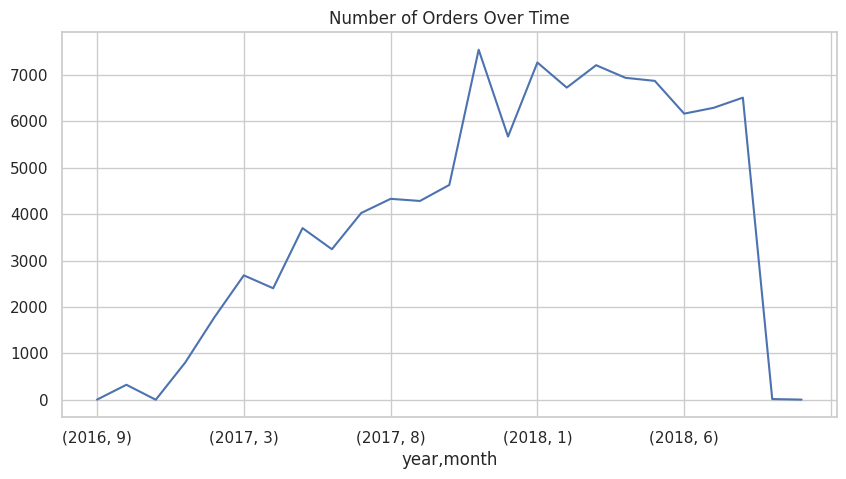

In [13]:
orders.groupby(['year', 'month']).size().plot(figsize=(10,5))
plt.title("Number of Orders Over Time")
plt.show()

## Key Initial Insights

1. Customer Behavior:
- Almost all customers made only one purchase
→ Indicates low retention and potential churn risk

2. Data Completeness:
- Missing values in delivery timestamps are likely due to order status
→ These fields should be handled carefully, not imputed blindly

3. Product Data:
- Some product attributes are missing
→ May affect product-level analysis but not overall revenue analysis

4. Time Trends:
- Strong growth observed in 2017 with seasonal peaks
- Sudden drop in late 2018 likely due to incomplete data